In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm

import sys  
sys.path.insert(1, '../../python_files/')
import qubits
import pulses

### Transmonin määrittely

In [2]:
E_C = 0.3*2*np.pi #Varausenergia (GHz)
E_J = 8*2*np.pi #Josephsonin energia (GHz)

qubit=qubits.Transmon(E_C,E_J,500)

In [3]:
print("Transmonin yksitoista ensimmäistä energiatasoa (GHz), kun E_0=0")
print(qubit.energies[0:11]-qubit.energies[0])

Transmonin yksitoista ensimmäistä energiatasoa (GHz), kun E_0=0
[  0.          25.48860139  48.57030326  69.5813038   82.4548144
 109.4189376  110.44497738 160.29841201 160.30648659 227.12458838
 227.12460681]


## Simulaatio

In [4]:
f_1 = qubit.frequency*1.2 #Ajotaajuudet
f_2 = qubit.frequency*1.4
f_ef = qubit.energies[2]-qubit.energies[1] #ef-siirtymän taajuus

dim = 7 #Hilbert-avaruuden dimensio

evolution_eigenbasis=qubits.time_evolution(qubit.H_D_eigbasis(dim))

In [5]:
list_c_vals=[np.float64(0.9930733865293206), np.float64(0.9917934035299109), np.float64(0.9903239429603026), np.float64(0.9887650048204959), np.float64(0.9871165891104907), np.float64(0.985378695830287), np.float64(0.983451324979885), np.float64(0.9813344765592843), np.float64(0.9791281505684851), np.float64(0.9768323470074877), np.float64(0.9742470658762915), np.float64(0.971672307174897), np.float64(0.9689080709033041), np.float64(0.9660543570615125), np.float64(0.9631111656495226), np.float64(0.9600784966673341), np.float64(0.9572563501149473), np.float64(0.9543447259923619), np.float64(0.950843624299578), np.float64(0.9483530450365956)]

In [6]:
def find_params(q,A,evolution,f_rabi,c_guess,lims,scale):

    #Rajat AC-stark siirtymälle
    min_range = lims[0]
    max_range = lims[1]
    
    #Arvot eri ajotaajuuksille/AC-stark siirtymille
    pulse_times=[]
    max_e_vals=[]
    max_f_vals=[]
    AC_stark_vals=[]
    c_vals=[]
    
    for i in range(min_range, max_range):
        f_1_shifted=f_1*(c_guess+i/scale)
        f_2_shifted=f_2*(c_guess+i/scale)

        c_vals.append(c_guess+i/scale)
        delta=q.frequency-2*f_1_shifted+f_2_shifted #AC-stark siirtymä
        AC_stark_vals.append(delta)

        if A < 3.3:
            sim_vals = pulses.sim_3_part_pulses(f_1_shifted,f_ef,A,evolution,dim,f_rabi,t_ramp=10,U_f=15,f_2=f_2_shifted,K=200)
        elif A < 3.8:
            sim_vals = pulses.sim_3_part_pulses(f_1_shifted,f_ef,A,evolution,dim,f_rabi,t_ramp=10,U_f=10,f_2=f_2_shifted,K=200)
        else:
            sim_vals = pulses.sim_3_part_pulses(f_1_shifted,f_ef,A,evolution,dim,f_rabi,t_ramp=10,U_f=1,f_2=f_2_shifted,K=200)
        
        max_e_vals.append(sim_vals[0])
        max_f_vals.append(sim_vals[1])
        pulse_times.append(sim_vals[2])

    plt.figure()
    plt.plot(AC_stark_vals, max_e_vals)
    plt.xlabel("delta=ω_q-2ω_1+ω_2 (GHz)")
    plt.ylabel("Suurin e-tason todennäköisyys")
    plt.show()
    
    index=np.argmax(max_e_vals)
    c=c_vals[index]
    e_max=max_e_vals[index]
    f_max=max_f_vals[index]
    pi_pulse=pulse_times[index]
    
    return(c,pi_pulse,[e_max,f_max],max_e_vals)

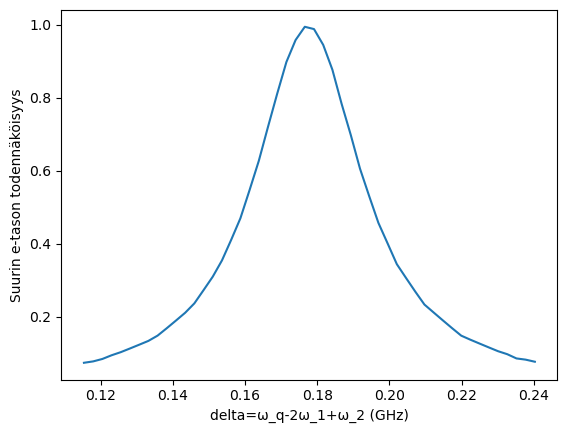

Amplitudi (GHz): 2.0390881111606896
AC-stark siirtymä (GHz): 0.9930733865293206
E-tason suurin todennäköisyys: 0.9973912560601627
Pulssin pituus (ns): 206.17175076434157
Rabi-taajuus (fourier):  0.0027082609397088035


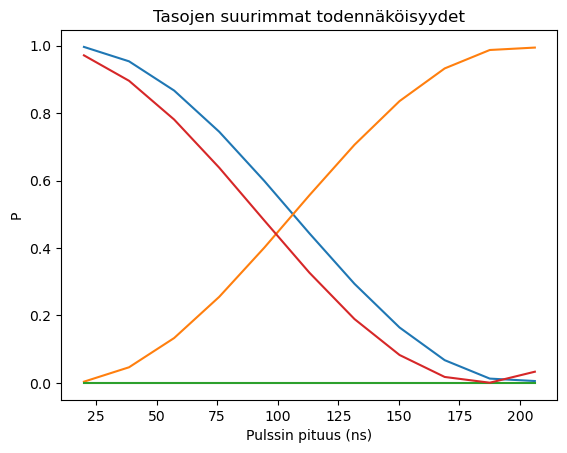

---------------------------------------------


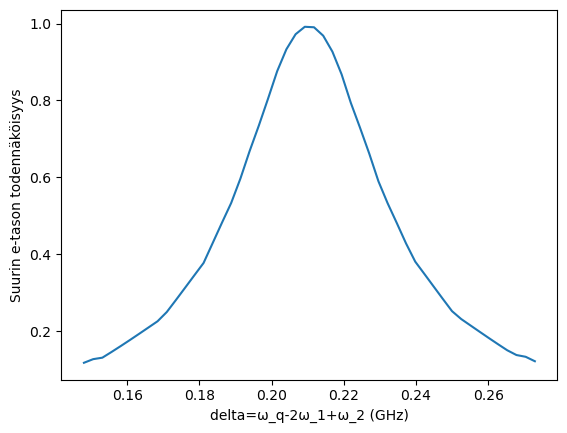

Amplitudi (GHz): 2.21348380487838
AC-stark siirtymä (GHz): 0.9917934035299109
E-tason suurin todennäköisyys: 0.9977269211884162
Pulssin pituus (ns): 150.48841345862317
Rabi-taajuus (fourier):  0.003498561496996008


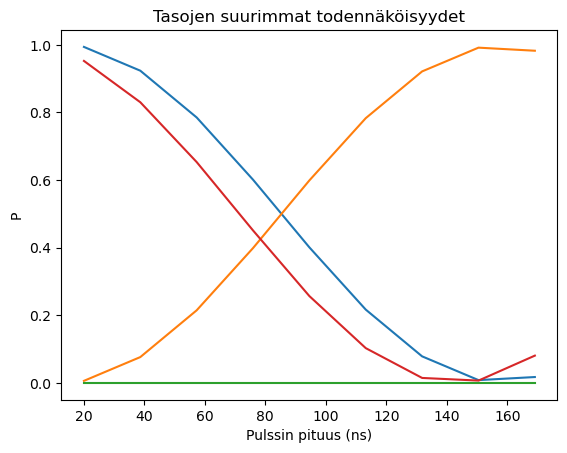

---------------------------------------------


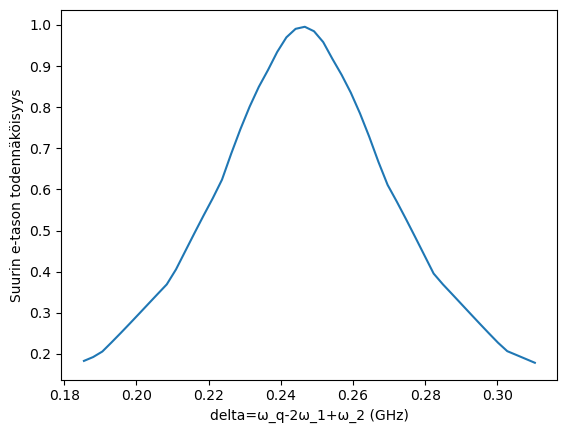

Amplitudi (GHz): 2.3878794985960705
AC-stark siirtymä (GHz): 0.9903239429603026
E-tason suurin todennäköisyys: 0.9997584710420061
Pulssin pituus (ns): 132.01317245041002
Rabi-taajuus (fourier):  0.004422808792921423


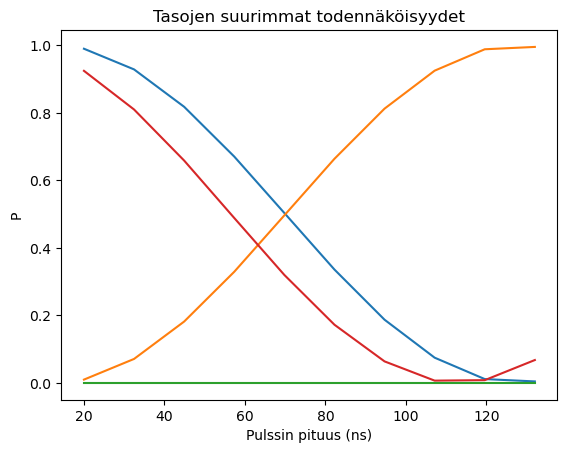

---------------------------------------------


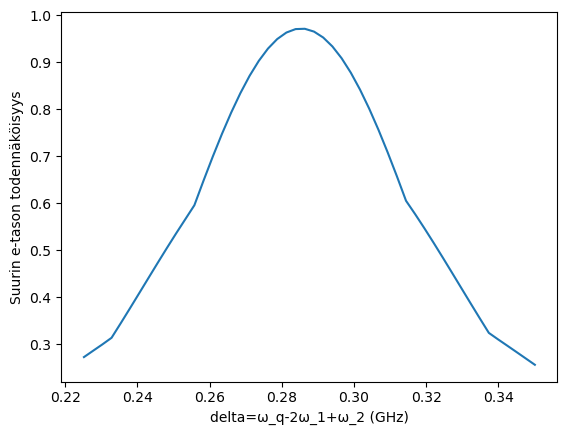

Amplitudi (GHz): 2.562275192313761
AC-stark siirtymä (GHz): 0.9887650048204959
E-tason suurin todennäköisyys: 0.9990362122908198
Pulssin pituus (ns): 94.79318548139817
Rabi-taajuus (fourier):  0.005469628101247997


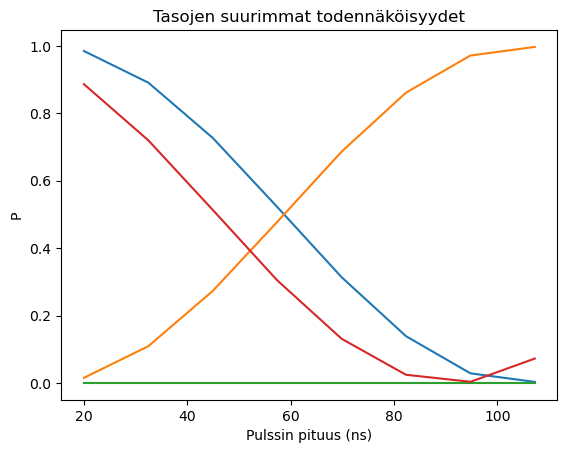

---------------------------------------------


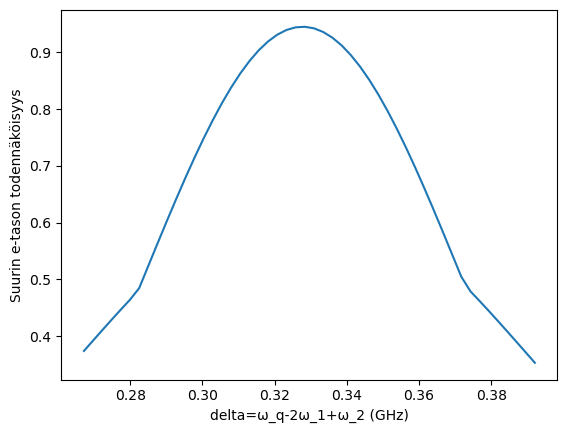

Amplitudi (GHz): 2.7366708860314515
AC-stark siirtymä (GHz): 0.9871165891104907
E-tason suurin todennäköisyys: 0.9992124980481468
Pulssin pituus (ns): 76.18856365515185
Rabi-taajuus (fourier):  0.006767955352529779


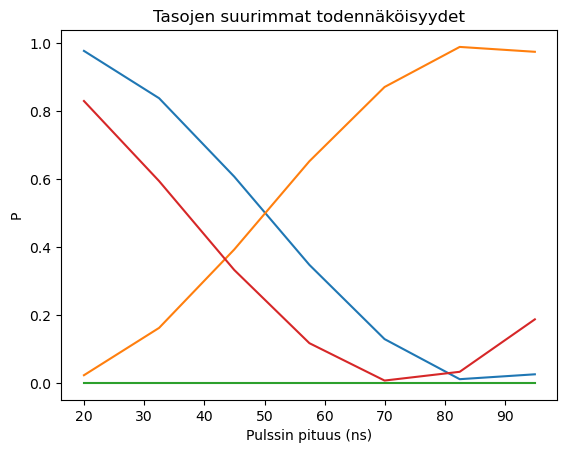

---------------------------------------------


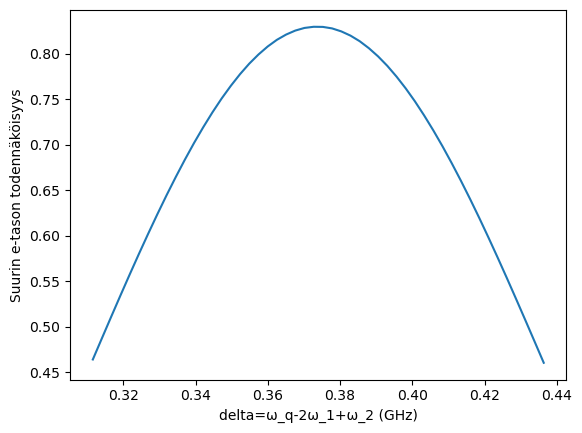

Amplitudi (GHz): 2.9110665797491424
AC-stark siirtymä (GHz): 0.985378695830287
E-tason suurin todennäköisyys: 0.9998414230302108
Pulssin pituus (ns): 57.52510822285523
Rabi-taajuus (fourier):  0.008130149657420462


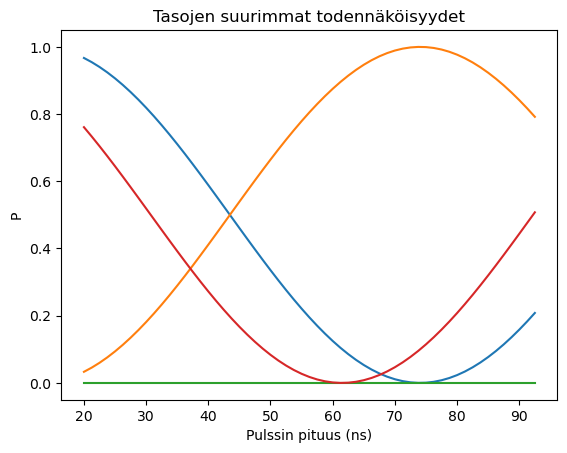

---------------------------------------------


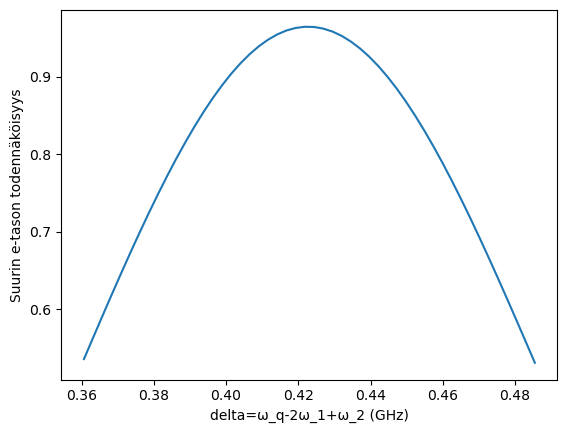

Amplitudi (GHz): 3.0854622734668324
AC-stark siirtymä (GHz): 0.983451324979885
E-tason suurin todennäköisyys: 0.9998442709582612
Pulssin pituus (ns): 57.59865004227206
Rabi-taajuus (fourier):  0.009830402310914962


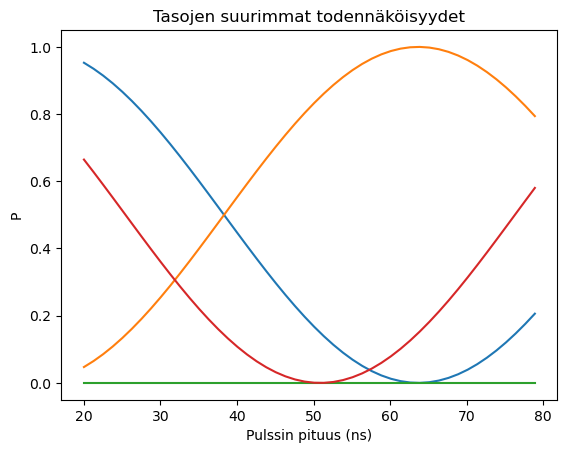

---------------------------------------------


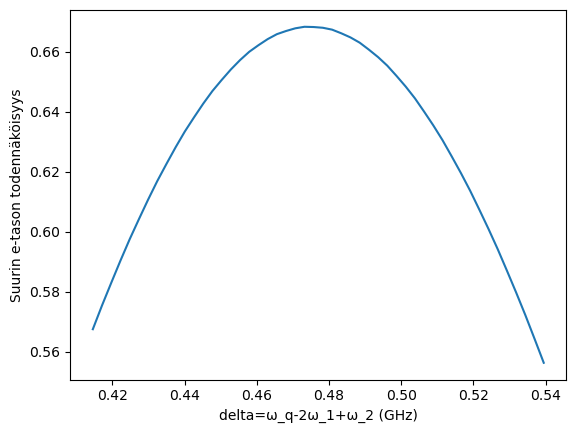

Amplitudi (GHz): 3.2598579671845234
AC-stark siirtymä (GHz): 0.9814344765592843
E-tason suurin todennäköisyys: 0.9993472932603968
Pulssin pituus (ns): 38.83795764499713
Rabi-taajuus (fourier):  0.011767458077185017


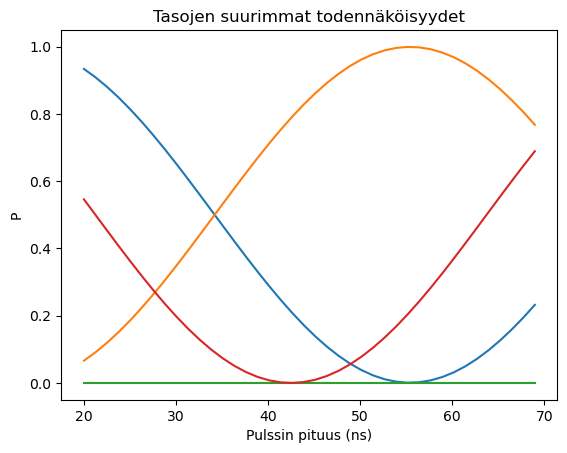

---------------------------------------------


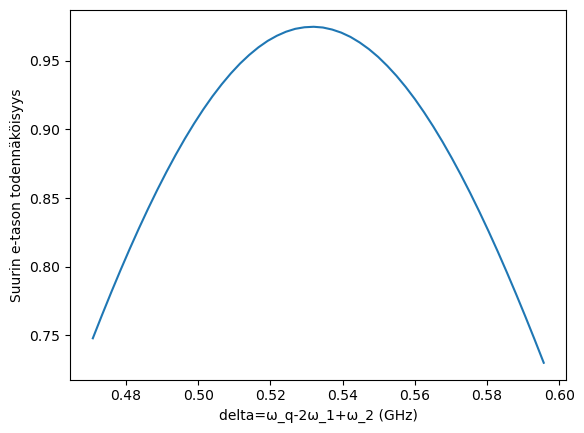

Amplitudi (GHz): 3.4342536609022134
AC-stark siirtymä (GHz): 0.9791281505684851
E-tason suurin todennäköisyys: 0.9999820133889376
Pulssin pituus (ns): 45.17644033967621
Rabi-taajuus (fourier):  0.014060061553940404


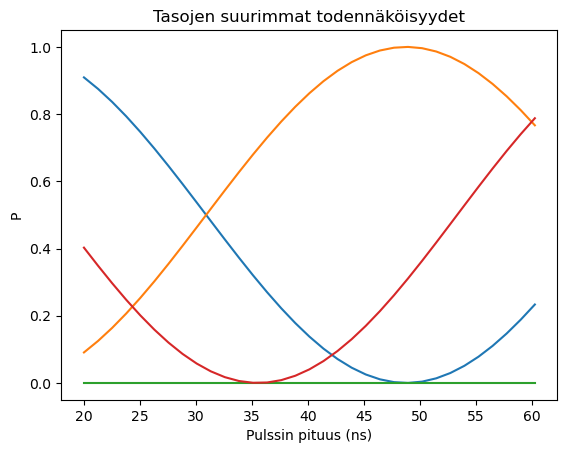

---------------------------------------------


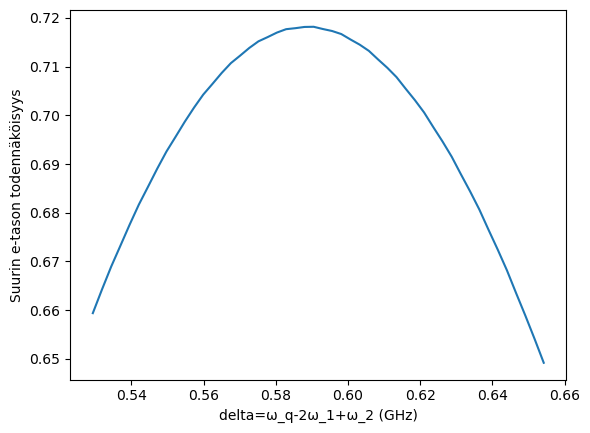

Amplitudi (GHz): 3.6086493546199043
AC-stark siirtymä (GHz): 0.9768323470074877
E-tason suurin todennäköisyys: 0.9997707181837494
Pulssin pituus (ns): 32.61780567730115
Rabi-taajuus (fourier):  0.01662652089876554


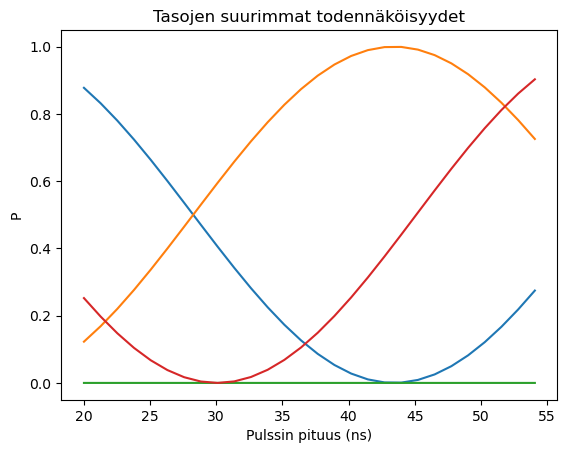

---------------------------------------------


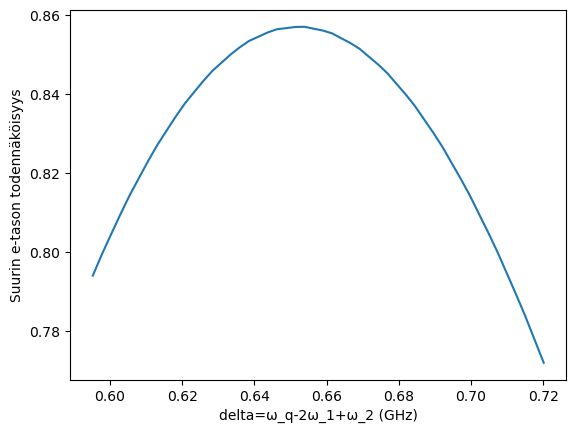

Amplitudi (GHz): 3.783045048337595
AC-stark siirtymä (GHz): 0.9743470658762915
E-tason suurin todennäköisyys: 0.9994706180902642
Pulssin pituus (ns): 32.64999009645234
Rabi-taajuus (fourier):  0.019599531889519285


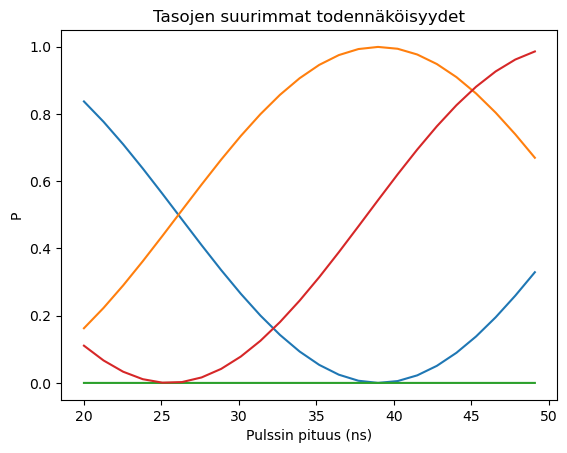

---------------------------------------------


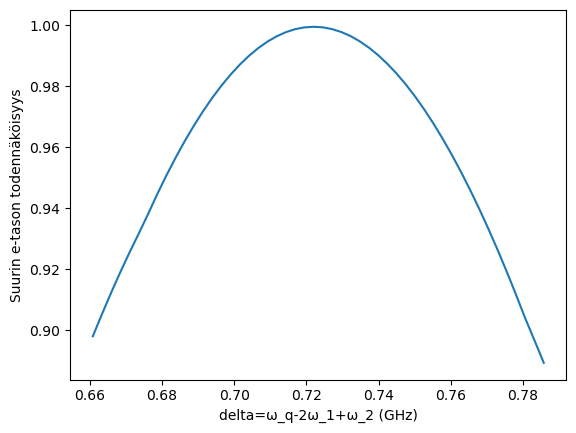

Amplitudi (GHz): 3.9574407420552853
AC-stark siirtymä (GHz): 0.971672307174897
E-tason suurin todennäköisyys: 0.9997929366387599
Pulssin pituus (ns): 35.22177463677448
Rabi-taajuus (fourier):  0.02296148586133967


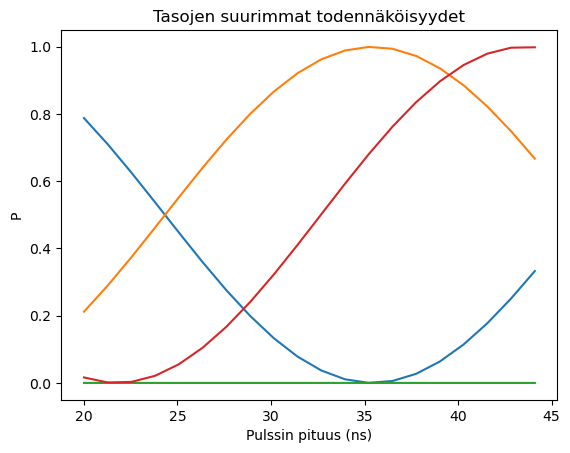

---------------------------------------------


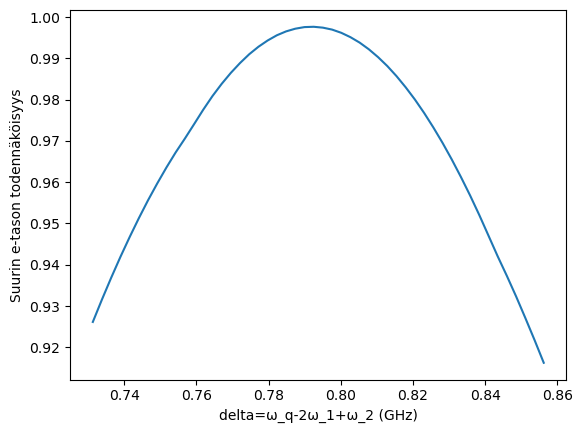

Amplitudi (GHz): 4.131836435772976
AC-stark siirtymä (GHz): 0.9689080709033041
E-tason suurin todennäköisyys: 0.9990542861785526
Pulssin pituus (ns): 32.721001201230116
Rabi-taajuus (fourier):  0.026647513468883128


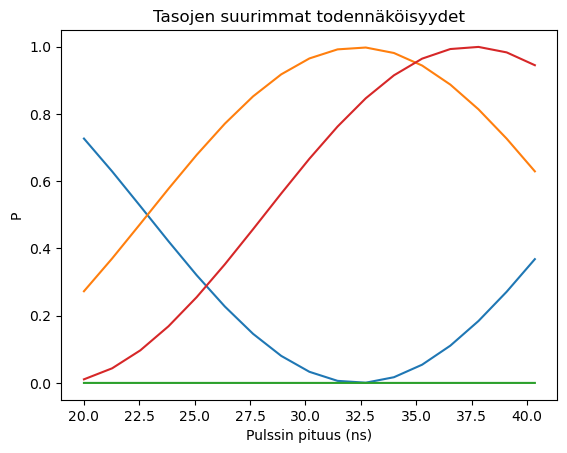

---------------------------------------------


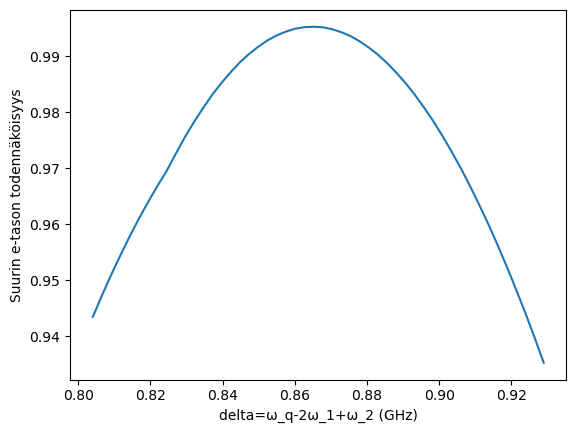

Amplitudi (GHz): 4.306232129490666
AC-stark siirtymä (GHz): 0.9660543570615125
E-tason suurin todennäköisyys: 0.9952687110660837
Pulssin pituus (ns): 30.206863117999625
Rabi-taajuus (fourier):  0.03093893491403065


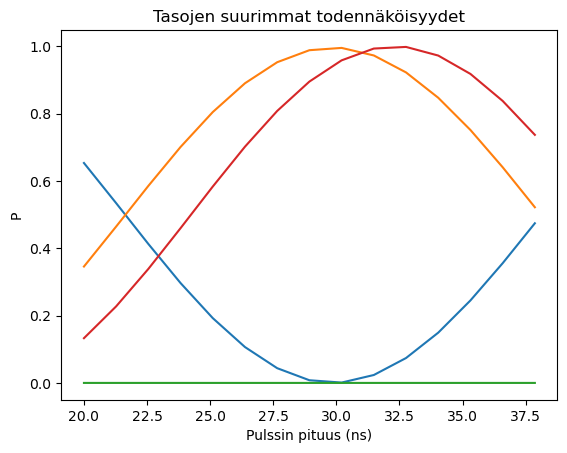

---------------------------------------------


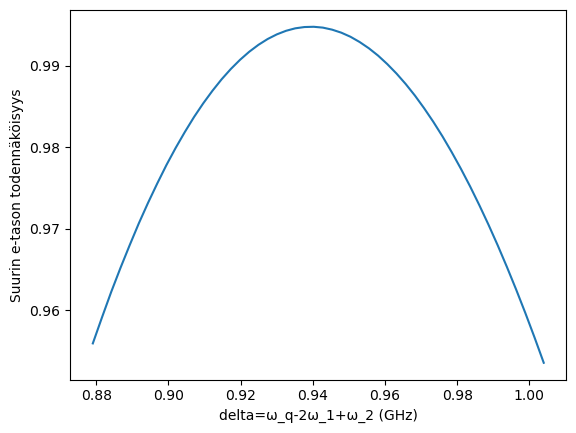

Amplitudi (GHz): 4.480627823208358
AC-stark siirtymä (GHz): 0.9631111656495226
E-tason suurin todennäköisyys: 0.9947769351820824
Pulssin pituus (ns): 27.6785408622255
Rabi-taajuus (fourier):  0.035518111789826085


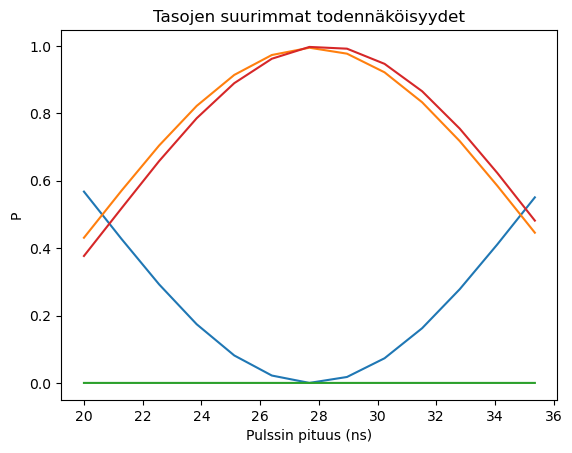

---------------------------------------------


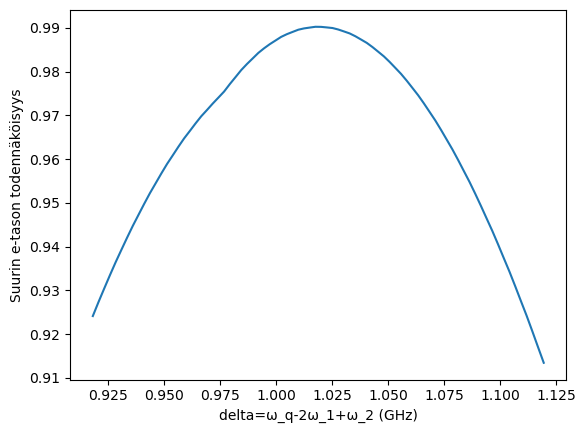

Amplitudi (GHz): 4.655023516926048
AC-stark siirtymä (GHz): 0.9600784966673341
E-tason suurin todennäköisyys: 0.9942982946490498
Pulssin pituus (ns): 26.418996351145886
Rabi-taajuus (fourier):  0.04099673536811785


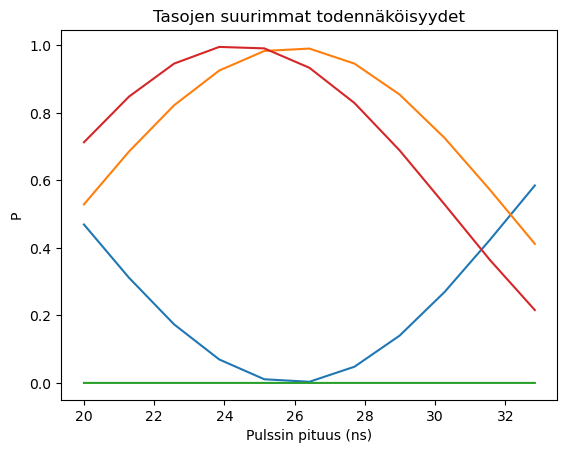

---------------------------------------------


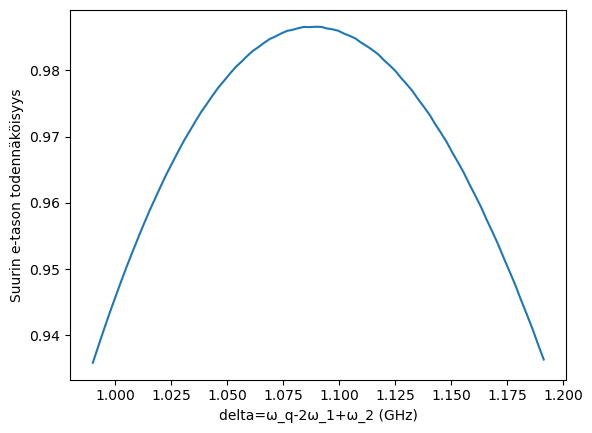

Amplitudi (GHz): 4.829419210643738
AC-stark siirtymä (GHz): 0.9572563501149473
E-tason suurin todennäköisyys: 0.989162868078605
Pulssin pituus (ns): 23.862752354381072
Rabi-taajuus (fourier):  0.04659889723343166


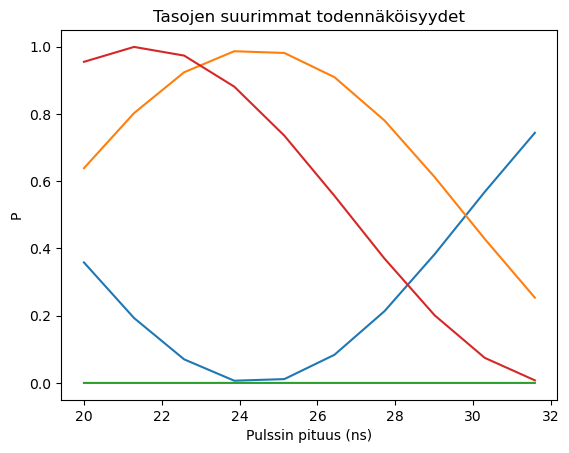

---------------------------------------------


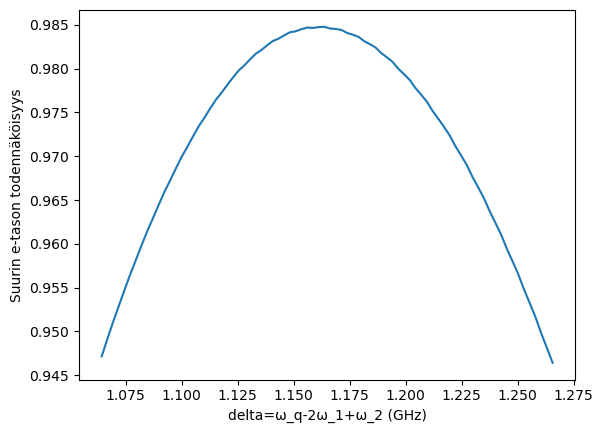

Amplitudi (GHz): 5.003814904361429
AC-stark siirtymä (GHz): 0.9543447259923619
E-tason suurin todennäköisyys: 0.9847717484993133
Pulssin pituus (ns): 22.583024854258195
Rabi-taajuus (fourier):  0.05279222773982874


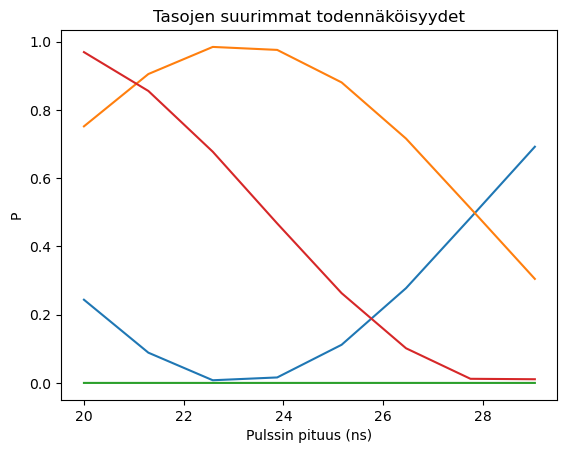

---------------------------------------------


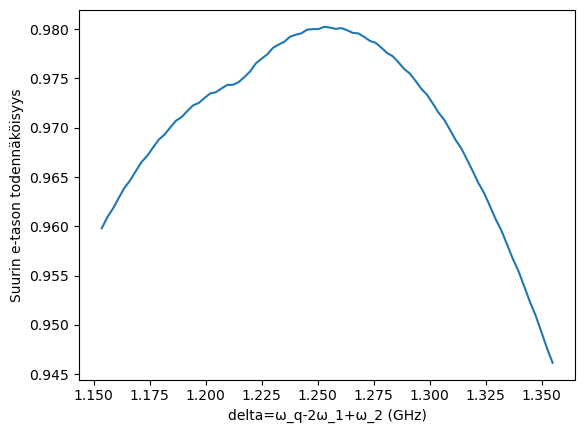

Amplitudi (GHz): 5.178210598079119
AC-stark siirtymä (GHz): 0.950843624299578
E-tason suurin todennäköisyys: 0.9915542790869143
Pulssin pituus (ns): 22.59253581111654
Rabi-taajuus (fourier):  0.06011263380660406


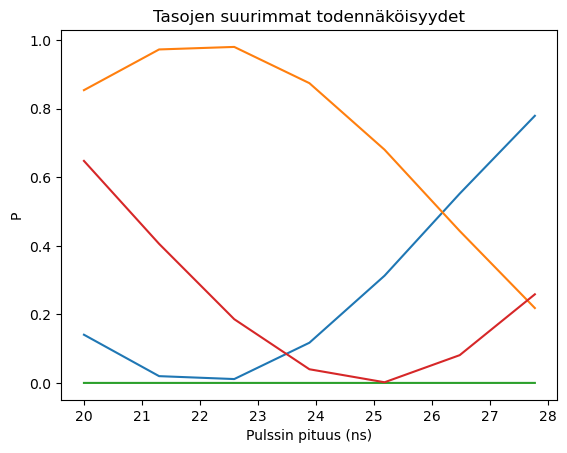

---------------------------------------------


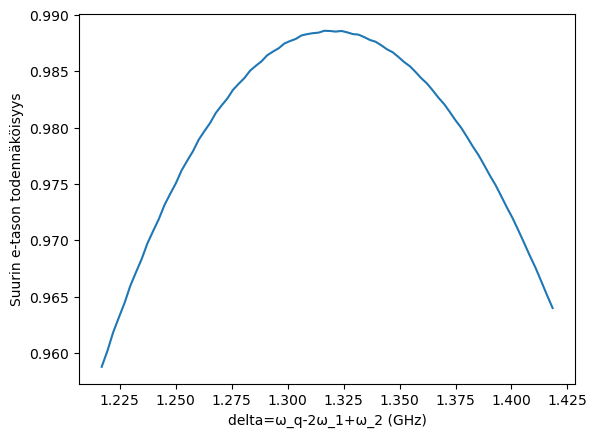

Amplitudi (GHz): 5.35260629179681
AC-stark siirtymä (GHz): 0.9483530450365956
E-tason suurin todennäköisyys: 0.9885975987616774
Pulssin pituus (ns): 21.29967218414603
Rabi-taajuus (fourier):  0.06789042282660185


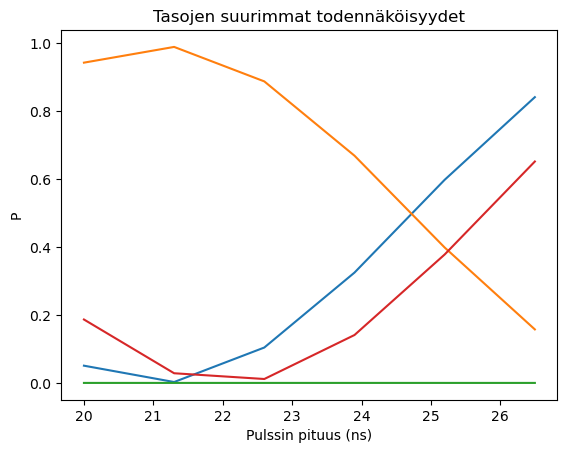

---------------------------------------------


In [7]:
c_vals = [] #c:n arvot
deltas = [] #AC Stark siirtymät
pulse_lengths = [] #Pulssin pituudet
max_vals = [] #Suurimmat tasojen todennäköisyydet
rabis = [] #Rabi taajuudet (fouriermuunnoksesta)
data = [] #e-tason suurimmat todennäköisyydet amplitudin ja AC-stark siirtymän suhteen
A_vals= []

min_range = 0.08
max_range = 0.21
N_data=20
d_data=(max_range-min_range)/(N_data-1)

for i in range (0,N_data):
    
    A = qubit.frequency*(min_range+i*d_data)
    A_vals.append(A)
    
    f_rabi= 0.0009703*A**3 - 0.00434*A**2 + 0.009973*A - 0.007682 #Arvaus Rabi-taajuudelle
    c=list_c_vals[i] #Arvaus c:n arvolle

    if i<15:
        params=find_params(qubit, A, evolution_eigenbasis,f_rabi*10,c,[-25,25],10000)
    else:
        params=find_params(qubit, A, evolution_eigenbasis,f_rabi*10,c,[-40,40],10000)

    c_vals.append(params[0])
    pulse_lengths.append(params[1])
    data.append(params[3])
    
    #Löydetyt optimaaliset ajotaajuudet
    f_1_opt = f_1*c_vals[-1]
    f_2_opt = f_2*c_vals[-1]
    deltas.append(qubit.frequency-2*f_1_opt+f_2_opt)

    m=10
    if A < 2.3:
        vals = pulses.sim_3_part_pulses(f_1_opt,f_ef,A,evolution_eigenbasis,dim,(f_rabi*10)/m,t_ramp=10,U_f=15,f_2=f_2_opt,K=200)
    elif A < 2.9:
        vals = pulses.sim_3_part_pulses(f_1_opt,f_ef,A,evolution_eigenbasis,dim,(f_rabi*10)/m,t_ramp=10,U_f=10,f_2=f_2_opt,K=200)
    else:
        vals = pulses.sim_3_part_pulses(f_1_opt,f_ef,A,evolution_eigenbasis,dim,(f_rabi*10)/m,t_ramp=10,U_f=1,f_2=f_2_opt,K=200)
    
    print("Amplitudi (GHz):", A)
    print("AC-stark siirtymä (GHz):", c_vals[-1])

    print("E-tason suurin todennäköisyys:", vals[0])
    print("Pulssin pituus (ns):", pulse_lengths[-1])

    g_vals=np.array([arr[0] for arr in vals[3]])
    e_vals=np.array([arr[1] for arr in vals[3]])
    f_vals=np.array([arr[2] for arr in vals[3]])

    max_vals.append([vals[0],vals[1]])

    g_vals_offset = g_vals-0.5 #Siirretään g-tason todennäköisyyksiä puolella alaspäin, dc-komponentin minimoinniksi
    fft_vals = np.fft.rfft(g_vals_offset) #Fourier-muunnos

    magnitude = np.abs(fft_vals) #Taajuuskomponentit
    magnitude[0] = 0 #Hylätään nollataajuus/vakiokomponentti

    #Taajuusavaruus
    freqs = np.fft.rfftfreq(len(g_vals), d=vals[4][1]-vals[4][0]) 
    frequency=freqs[np.argmax(magnitude)] #Suurin g-tason aikakehityksen taajuuskomponentti=Rabi-taajuus
    print("Rabi-taajuus (fourier): ",frequency)
    rabis.append(frequency)

    n_picked = int(len(vals[3])/m) #Plottausta varten käytetty pisteiden määrä
    
    plot_vals= 0.5*(1+np.cos(2*np.pi*frequency*vals[4][:n_picked])) #Sovite Rabi-taajuudella

    plt.figure()
    plt.plot(vals[4][:n_picked], g_vals[:n_picked])
    plt.plot(vals[4][:n_picked], e_vals[:n_picked])
    plt.plot(vals[4][:n_picked], f_vals[:n_picked])
    plt.plot(vals[4][:n_picked], plot_vals)
    plt.xlabel("Pulssin pituus (ns)")
    plt.ylabel("P")
    plt.title("Tasojen suurimmat todennäköisyydet")
    plt.show()

    print("---------------------------------------------")

[np.float64(2.0390881111606896), np.float64(2.21348380487838), np.float64(2.3878794985960705), np.float64(2.562275192313761), np.float64(2.7366708860314515), np.float64(2.9110665797491424), np.float64(3.0854622734668324), np.float64(3.2598579671845234), np.float64(3.4342536609022134), np.float64(3.6086493546199043), np.float64(3.783045048337595), np.float64(3.9574407420552853), np.float64(4.131836435772976), np.float64(4.306232129490666), np.float64(4.480627823208358), np.float64(4.655023516926048), np.float64(4.829419210643738), np.float64(5.003814904361429), np.float64(5.178210598079119), np.float64(5.35260629179681)]


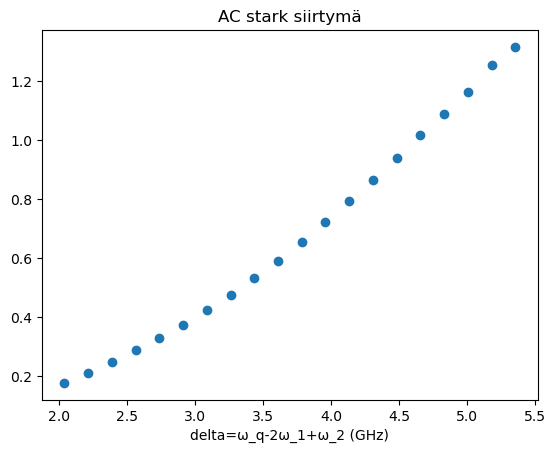

[np.float64(0.17654968973334917), np.float64(0.2091746661906484), np.float64(0.24662916090699838), np.float64(0.28636431374342664), np.float64(0.3283801246999545), np.float64(0.3726765937765748), np.float64(0.4218025811122317), np.float64(0.47320922656798103), np.float64(0.5319942504217252), np.float64(0.5905110722566036), np.float64(0.6538574123505256), np.float64(0.7220332707034913), np.float64(0.7924897871765424), np.float64(0.8652269617697002), np.float64(0.9402447944829291), np.float64(1.0175432853162576), np.float64(1.089475853852825), np.float64(1.163689080509478), np.float64(1.2529272659809862), np.float64(1.3164086480441242)]
[np.float64(0.9930733865293206), np.float64(0.9917934035299109), np.float64(0.9903239429603026), np.float64(0.9887650048204959), np.float64(0.9871165891104907), np.float64(0.985378695830287), np.float64(0.983451324979885), np.float64(0.9814344765592843), np.float64(0.9791281505684851), np.float64(0.9768323470074877), np.float64(0.9743470658762915), np.flo

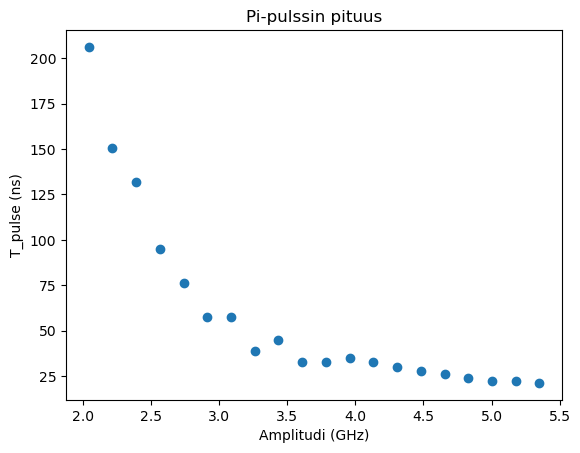

[np.float64(206.17175076434157), np.float64(150.48841345862317), np.float64(132.01317245041002), np.float64(94.79318548139817), np.float64(76.18856365515185), np.float64(57.52510822285523), np.float64(57.59865004227206), np.float64(38.83795764499713), np.float64(45.17644033967621), np.float64(32.61780567730115), np.float64(32.64999009645234), np.float64(35.22177463677448), np.float64(32.721001201230116), np.float64(30.206863117999625), np.float64(27.6785408622255), np.float64(26.418996351145886), np.float64(23.862752354381072), np.float64(22.583024854258195), np.float64(22.59253581111654), np.float64(21.29967218414603)]


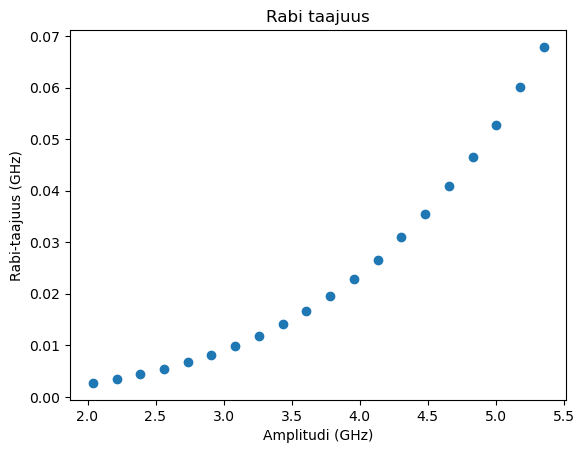

[np.float64(0.0027082609397088035), np.float64(0.003498561496996008), np.float64(0.004422808792921423), np.float64(0.005469628101247997), np.float64(0.006767955352529779), np.float64(0.008130149657420462), np.float64(0.009830402310914962), np.float64(0.011767458077185017), np.float64(0.014060061553940404), np.float64(0.01662652089876554), np.float64(0.019599531889519285), np.float64(0.02296148586133967), np.float64(0.026647513468883128), np.float64(0.03093893491403065), np.float64(0.035518111789826085), np.float64(0.04099673536811785), np.float64(0.04659889723343166), np.float64(0.05279222773982874), np.float64(0.06011263380660406), np.float64(0.06789042282660185)]


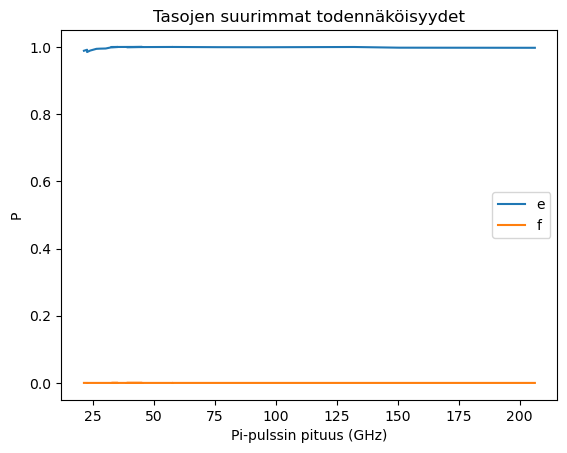

[np.float64(0.9973912560601627), np.float64(0.9977269211884162), np.float64(0.9997584710420061), np.float64(0.9990362122908198), np.float64(0.9992124980481468), np.float64(0.9998414230302108), np.float64(0.9998442709582612), np.float64(0.9993472932603968), np.float64(0.9999820133889376), np.float64(0.9997707181837494), np.float64(0.9994706180902642), np.float64(0.9997929366387599), np.float64(0.9990542861785526), np.float64(0.9952687110660837), np.float64(0.9947769351820824), np.float64(0.9942982946490498), np.float64(0.989162868078605), np.float64(0.9847717484993133), np.float64(0.9915542790869143), np.float64(0.9885975987616774)]
[np.float64(2.154594726761625e-08), np.float64(1.833726130245628e-08), np.float64(3.8767883019986714e-08), np.float64(7.448389904932496e-08), np.float64(1.309086755311772e-07), np.float64(1.9282200267856173e-07), np.float64(2.7695705274891065e-07), np.float64(2.995046506358598e-07), np.float64(3.335675739904565e-07), np.float64(7.009925831402046e-07), np.flo

'\nplt.figure(figsize=(6, 6))\nplt.imshow(data, aspect=\'auto\')  # stretches to square\nplt.colorbar(label="e-tason suurin todennäköisyys")\nplt.show() '

In [8]:
print(A_vals)

plt.figure()
plt.plot(A_vals, deltas, 'o')
plt.xlabel("Amplitudi (GHz)")
plt.xlabel("delta=ω_q-2ω_1+ω_2 (GHz)")
plt.title("AC stark siirtymä")
plt.show()
print(deltas)
print(c_vals)

plt.figure()
plt.plot(A_vals, pulse_lengths, 'o')
plt.xlabel("Amplitudi (GHz)")
plt.ylabel("T_pulse (ns)")
plt.title("Pi-pulssin pituus")
plt.show()
print(pulse_lengths)

plt.figure()
plt.plot(A_vals, rabis, 'o')
plt.xlabel("Amplitudi (GHz)")
plt.ylabel("Rabi-taajuus (GHz)")
plt.title("Rabi taajuus")
plt.show()
print(rabis)

e_vals=[arr[0] for arr in max_vals]
f_vals=[arr[1] for arr in max_vals]

plt.figure()
plt.plot(pulse_lengths, e_vals)
plt.plot(pulse_lengths, f_vals)
plt.legend(["e","f"])
plt.xlabel("Pi-pulssin pituus (GHz)")
plt.ylabel("P")
plt.title("Tasojen suurimmat todennäköisyydet")
plt.show()
print(e_vals)
print(f_vals)

"""
plt.figure(figsize=(6, 6))
plt.imshow(data, aspect='auto')  # stretches to square
plt.colorbar(label="e-tason suurin todennäköisyys")
plt.show() """